# **Proyecto de Machine Learning**

### **Problema de negocio**

- El problema planteado consiste en predecir si un producto generará beneficios o pérdidas. Dado que se dispone de un histórico de ventas con características de cada producto y una etiqueta binaria (Profit_Class), el enfoque adecuado es un modelo de Machine Learning supervisado de clasificación. Este tipo de modelos permite aprender patrones complejos entre múltiples variables (precio, descuento, categoría, región, etc.) que no pueden capturarse mediante reglas simples o análisis estadísticos tradicionales. Para garantizar un rendimiento óptimo, se evaluaron varios algoritmos (Logistic Regression, Decision Tree, Random Forest, LightGBM y XGBoost) y se optimizaron sus hiperparámetros mediante validación cruzada. La métrica principal seleccionada fue el recall de la clase 0, ya que para el negocio es importante identificar correctamente los productos que generan pérdidas.

### **1- Importación de modulos y paquetes**

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import sys
sys.path.append("src")
from utils.toolbox_ML import describe_df
import utils.bootcampviztools as bt

from sklearn.model_selection import train_test_split


pd.options.mode.copy_on_write = True

### **2- Carga de datos**

In [2]:
df = pd.read_csv("src/data_sample/Superstore.csv", encoding= "latin1")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


### **3- Creación de un target binario**

In [3]:
def clasificar_profit(x):
    if x > 0:
        return 1 # -> beneficio
    else:
        return 0 # -> pérdida 

df["Profit_Class"] = df["Profit"].apply(clasificar_profit)

In [4]:
df = df.drop(columns=["Profit"])

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit_Class
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,1
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,1
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,1
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,0
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,1


In [6]:
df.columns = df.columns.str.replace(" ", "_")

- Visualizamos solo un poco los datos

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9994 non-null   int64  
 1   Order_ID       9994 non-null   object 
 2   Order_Date     9994 non-null   object 
 3   Ship_Date      9994 non-null   object 
 4   Ship_Mode      9994 non-null   object 
 5   Customer_ID    9994 non-null   object 
 6   Customer_Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal_Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product_ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product_Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.duplicated().sum()

np.int64(0)

### **4- Dividimos el dataset en X_train, X_test, y_train e y_test**

In [9]:
X = df.drop(["Profit_Class"], axis=1)
y = df["Profit_Class"].copy()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify=y)

In [11]:
X_train.shape

(7995, 20)

In [12]:
X_test.shape

(1999, 20)

##### - Damos un primer vistazo de los datos de entrenamiento

In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7995 entries, 2667 to 4099
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         7995 non-null   int64  
 1   Order_ID       7995 non-null   object 
 2   Order_Date     7995 non-null   object 
 3   Ship_Date      7995 non-null   object 
 4   Ship_Mode      7995 non-null   object 
 5   Customer_ID    7995 non-null   object 
 6   Customer_Name  7995 non-null   object 
 7   Segment        7995 non-null   object 
 8   Country        7995 non-null   object 
 9   City           7995 non-null   object 
 10  State          7995 non-null   object 
 11  Postal_Code    7995 non-null   int64  
 12  Region         7995 non-null   object 
 13  Product_ID     7995 non-null   object 
 14  Category       7995 non-null   object 
 15  Sub-Category   7995 non-null   object 
 16  Product_Name   7995 non-null   object 
 17  Sales          7995 non-null   float64
 18  Quantity  

Podemos observar que no hay columnas con nulos y que la mayoría son de tipo object por lo tanto tendremos que aplicar varias transformaciones.

In [14]:
X_train.describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount
count,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000
mean,4975.072545,55239.642777,227.610270,3.789118,0.156306
std,2880.026057,32135.065867,636.220268,2.229413,0.206263
min,1.000000,1040.000000,0.556000,1.000000,0.000000
25%,2488.500000,23223.000000,17.145000,2.000000,0.000000
50%,4972.000000,58103.000000,54.816000,3.000000,0.200000
75%,7446.500000,90008.000000,207.000000,5.000000,0.200000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000


Las variables Sales, Quantity y Discount presentan posibles outliers, ya que existe una diferencia muy grande entre el tercer cuartil y el valor máximo. Esto nos indica que hay valores extremos alejados del resto de la distribución.

### **5- Distribución del target**

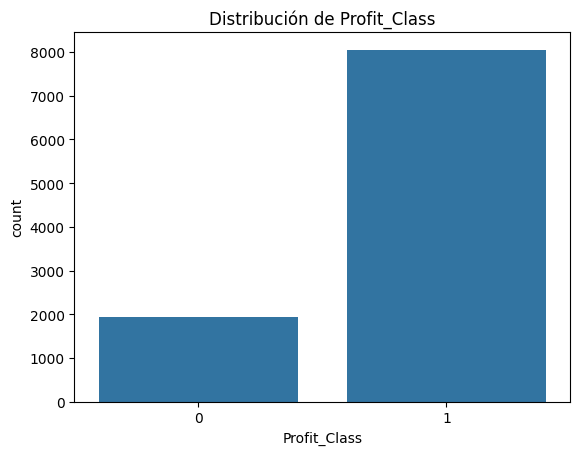

In [15]:
sns.countplot(data=df, x="Profit_Class")
plt.title("Distribución de Profit_Class")
plt.show()

El target se encuentra desbalanceado tendremos que aplicar técnicas de balanceado como "class_weight"

### **6- Transformación de variables**

In [16]:
describe_df(X_train)

,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
Row_ID,int64,0.0,7995,100.00
Sales,float64,0.0,5023,62.83
Order_ID,object,0.0,4450,55.66
Product_ID,object,0.0,1830,22.89
Product_Name,object,0.0,1818,22.74
Ship_Date,object,0.0,1303,16.30
Order_Date,object,0.0,1210,15.13
Customer_ID,object,0.0,791,9.89
Customer_Name,object,0.0,791,9.89
Postal_Code,int64,0.0,611,7.64


Eliminaremos variables con alta cardinalidad o aquellas que no le aporten información al modelo

In [17]:
cols_to_drop = ["Row_ID", "Order_ID", "Product_ID","Customer_ID", "Postal_Code", "Customer_Name", "Country"]
X_train = X_train.drop(columns=cols_to_drop, errors="ignore") 
X_test = X_test.drop(columns=cols_to_drop, errors="ignore")

In [18]:
X_train.head()

,Order_Date,Ship_Date,Ship_Mode,Segment,City,State,Region,Category,Sub-Category,Product_Name,Sales,Quantity,Discount
2667,10/1/2016,10/1/2016,Same Day,Consumer,Amarillo,Texas,Central,Office Supplies,Paper,Easy-staple paper,28.352,1,0.2
4055,9/29/2014,10/3/2014,Standard Class,Corporate,Philadelphia,Pennsylvania,East,Office Supplies,Storage,Tennsco Single-Tier Lockers,1801.632,6,0.2
8533,11/30/2016,12/6/2016,Standard Class,Consumer,Detroit,Michigan,Central,Furniture,Chairs,High-Back Leather Manager's Chair,389.970,3,0.0
224,12/24/2015,12/27/2015,First Class,Consumer,Dublin,Ohio,East,Office Supplies,Art,Stanley Bostitch Contemporary Electric Pencil ...,27.168,2,0.2
847,10/13/2015,10/17/2015,Standard Class,Consumer,Louisville,Kentucky,South,Furniture,Chairs,Global Deluxe Office Fabric Chairs,287.940,3,0.0


In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7995 entries, 2667 to 4099
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_Date    7995 non-null   object 
 1   Ship_Date     7995 non-null   object 
 2   Ship_Mode     7995 non-null   object 
 3   Segment       7995 non-null   object 
 4   City          7995 non-null   object 
 5   State         7995 non-null   object 
 6   Region        7995 non-null   object 
 7   Category      7995 non-null   object 
 8   Sub-Category  7995 non-null   object 
 9   Product_Name  7995 non-null   object 
 10  Sales         7995 non-null   float64
 11  Quantity      7995 non-null   int64  
 12  Discount      7995 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 874.5+ KB


- **Order_date y Ship_Date** -> Extraeremos año,mes y día

In [20]:
X_train["Order_Date"] = pd.to_datetime(X_train["Order_Date"])
X_test["Order_Date"] = pd.to_datetime(X_test["Order_Date"])

X_train["Ship_Date"] = pd.to_datetime(X_train["Ship_Date"])
X_test["Ship_Date"] = pd.to_datetime(X_test["Ship_Date"])

In [21]:
X_train["Order_Year"] = X_train["Order_Date"].dt.year
X_train["Order_Month"] = X_train["Order_Date"].dt.month
X_train["Order_Day"] = X_train["Order_Date"].dt.day

X_test["Order_Year"] = X_test["Order_Date"].dt.year
X_test["Order_Month"] = X_test["Order_Date"].dt.month
X_test["Order_Day"] = X_test["Order_Date"].dt.day

In [22]:
X_train["Ship_Year"] = X_train["Ship_Date"].dt.year
X_train["Ship_Month"] = X_train["Ship_Date"].dt.month
X_train["Ship_Day"] = X_train["Ship_Date"].dt.day

X_test["Ship_Year"] = X_test["Ship_Date"].dt.year
X_test["Ship_Month"] = X_test["Ship_Date"].dt.month
X_test["Ship_Day"] = X_test["Ship_Date"].dt.day

- **Con los datos que disponemos podemos crear la columna (Delivery_Days)** -> podría explicar si un pedido con retraso tiene más probabilidad de generar pérdidas.

In [23]:
X_train["Delivery_Days"] = (X_train["Ship_Date"] - X_train["Order_Date"]).dt.days
X_test["Delivery_Days"] = (X_test["Ship_Date"] - X_test["Order_Date"]).dt.days

In [24]:
X_train = X_train.drop(columns=["Order_Date", "Ship_Date"], errors="ignore") 
X_test = X_test.drop(columns=["Order_Date", "Ship_Date"], errors="ignore")

- **Podemos crear una columna que se llame (Impact_Sales_Delay) para medir el riesgo financiero** ya que un retraso de entrega castiga mucho más al beneficio de un producto caro (Sales alto) que al de uno barato.

In [27]:
X_train["Impact_Sales_Delay"] = X_train["Sales"] * X_train["Delivery_Days"]
X_test["Impact_Sales_Delay"] = X_test["Sales"] * X_test["Delivery_Days"]

- **Ship_Mode** -> podemos aplicar get dummies ya que no tenemos tantas categorias

In [28]:
X_train["Ship_Mode"].value_counts()

Ship_Mode
Standard Class    4754
Second Class      1564
First Class       1243
Same Day           434
Name: count, dtype: int64

- **Segment**-> se puede aplicar get dummies

In [29]:
X_train["Segment"].value_counts()

Segment
Consumer       4125
Corporate      2433
Home Office    1437
Name: count, dtype: int64

- **City y State**

In [30]:
X_train["City"].value_counts()

City
New York City      737
Los Angeles        598
Philadelphia       423
San Francisco      418
Seattle            331
                  ... 
North Miami          1
San Luis Obispo      1
Murrieta             1
Champaign            1
Billings             1
Name: count, Length: 516, dtype: int64

In [31]:
X_train["State"].value_counts()

State
California              1622
New York                 904
Texas                    788
Pennsylvania             461
Washington               393
Illinois                 391
Ohio                     372
Florida                  306
Michigan                 202
North Carolina           191
Arizona                  182
Virginia                 178
Tennessee                152
Colorado                 151
Georgia                  144
Kentucky                 116
Indiana                  115
Massachusetts            112
New Jersey               106
Oregon                    99
Maryland                  86
Wisconsin                 80
Delaware                  72
Minnesota                 68
Connecticut               66
Oklahoma                  54
Alabama                   53
Rhode Island              51
Arkansas                  48
Missouri                  47
Utah                      45
Mississippi               43
Nevada                    34
Louisiana                 34
Nebraska

Eliminamos City y nos quedamos con State porque City tiene demasiadas categorías y aporta mucho ruido, mientras que State resume la información geográfica de forma estable y útil para el modelo.
Además, para evitar que el modelo recibiera categorías muy poco frecuentes, se agruparon los estados con baja aparición dentro de la categoría "Other".

In [32]:
counts = df["State"].value_counts()
rare_states = counts[counts <= 3].index

In [33]:
X_train["State_grouped"] = X_train["State"].replace(rare_states, "Other")
X_test["State_grouped"] = X_test["State"].replace(rare_states, "Other")

In [34]:
X_train = X_train.drop(columns=["State"], errors="ignore") 
X_test = X_test.drop(columns=["State"], errors="ignore")

X_train = X_train.drop(columns=["City"], errors="ignore") 
X_test = X_test.drop(columns=["City"], errors="ignore")

- **Region**-> aplicar get dummies

- **Product Name**-> No eliminaremos esta variable porque es relevante para el negocio ya que distintos productos tienen comportamientos distintos en términos de pérdidas y beneficios. Como la columna tiene alta cardinalidad la transformamos con CatBoostEncoder para conservar su información sin generar miles de categorías ni provocar sobreajuste.


In [35]:
X_train["Product_Name"].value_counts()

Product_Name
Easy-staple paper                                                            37
Staples                                                                      36
Staple envelope                                                              35
KI Adjustable-Height Table                                                   16
Staples in misc. colors                                                      15
                                                                             ..
Xerox 1980                                                                    1
Okidata MB760 Printer                                                         1
Hewlett-Packard Deskjet 6540 Color Inkjet Printer                             1
Belkin 7 Outlet SurgeMaster Surge Protector with Phone Protection             1
Snap-A-Way Black Print Carbonless Speed Message, No Reply Area, Duplicate     1
Name: count, Length: 1818, dtype: int64

In [36]:
import category_encoders as ce

te_product = ce.CatBoostEncoder(cols=["Product_Name"])
te_product.fit(X_train["Product_Name"], y_train)

# Transformar
X_train["ProductName_TE"] = te_product.transform(X_train["Product_Name"])
X_test["ProductName_TE"] = te_product.transform(X_test["Product_Name"])

X_train = X_train.drop(columns=["Product_Name"])
X_test = X_test.drop(columns=["Product_Name"])

- **Revisamos cómo quedaron nuestros datos**

In [37]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7995 entries, 2667 to 4099
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ship_Mode           7995 non-null   object 
 1   Segment             7995 non-null   object 
 2   Region              7995 non-null   object 
 3   Category            7995 non-null   object 
 4   Sub-Category        7995 non-null   object 
 5   Sales               7995 non-null   float64
 6   Quantity            7995 non-null   int64  
 7   Discount            7995 non-null   float64
 8   Order_Year          7995 non-null   int32  
 9   Order_Month         7995 non-null   int32  
 10  Order_Day           7995 non-null   int32  
 11  Ship_Year           7995 non-null   int32  
 12  Ship_Month          7995 non-null   int32  
 13  Ship_Day            7995 non-null   int32  
 14  Delivery_Days       7995 non-null   int64  
 15  Impact_Sales_Delay  7995 non-null   float64
 16  State_gr

In [38]:
X_train.describe()

,Sales,Quantity,Discount,Order_Year,Order_Month,Order_Day,Ship_Year,Ship_Month,Ship_Day,Delivery_Days,Impact_Sales_Delay,ProductName_TE
count,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000
mean,227.610270,3.789118,0.156306,2015.725078,7.828643,15.455535,2015.739712,7.768730,15.876798,3.956098,889.212352,0.804569
std,636.220268,2.229413,0.206263,1.123014,3.273025,8.764501,1.125552,3.327984,8.803214,1.748282,2903.317053,0.215635
min,0.556000,1.000000,0.000000,2014.000000,1.000000,1.000000,2014.000000,1.000000,1.000000,0.000000,0.000000,0.080625
25%,17.145000,2.000000,0.000000,2015.000000,5.000000,8.000000,2015.000000,5.000000,8.000000,3.000000,53.890000,0.686608
50%,54.816000,3.000000,0.200000,2016.000000,9.000000,15.000000,2016.000000,9.000000,16.000000,4.000000,189.700000,0.935418
75%,207.000000,5.000000,0.200000,2017.000000,11.000000,23.000000,2017.000000,11.000000,24.000000,5.000000,738.912000,0.967709
max,22638.480000,14.000000,0.800000,2017.000000,12.000000,31.000000,2018.000000,12.000000,31.000000,7.000000,122499.650000,0.994901


Creamos listas de features categóricas y númericas para nuestro Mini-EDA

In [39]:
features_num = X_train.select_dtypes(include=["int64", "int32","float64"]).columns.tolist()
features_cat = X_train.select_dtypes(include=["object"]).columns.tolist()

features_num, features_cat

(['Sales',
  'Quantity',
  'Discount',
  'Order_Year',
  'Order_Month',
  'Order_Day',
  'Ship_Year',
  'Ship_Month',
  'Ship_Day',
  'Delivery_Days',
  'Impact_Sales_Delay',
  'ProductName_TE'],
 ['Ship_Mode',
  'Segment',
  'Region',
  'Category',
  'Sub-Category',
  'State_grouped'])

### **7- Mini-EDA**

- **Features categóricas**

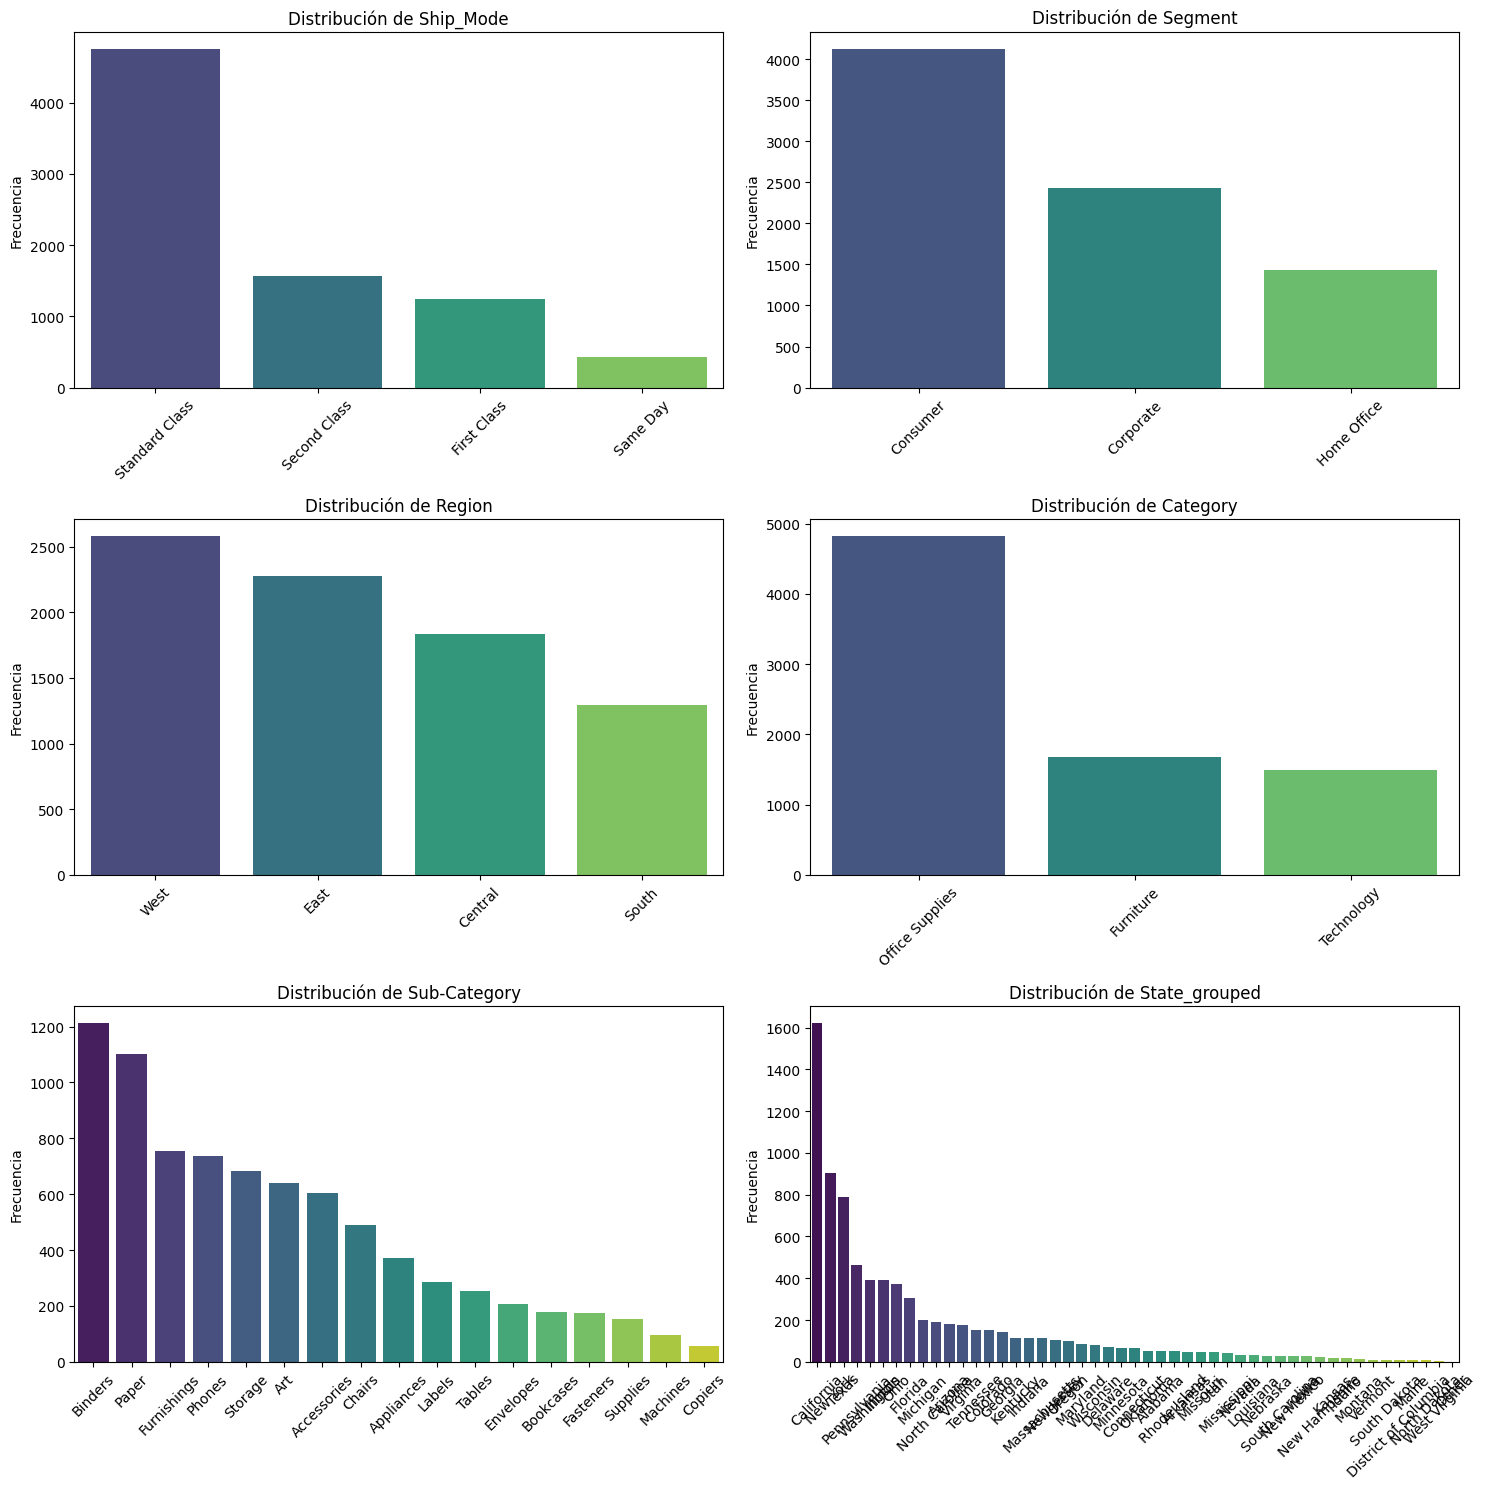

In [40]:
bt.pinta_distribucion_categoricas(X_train, features_cat, relativa=False, mostrar_valores=False)

Todas las variables aportan información relevante al modelo así que nos las quedaremos todas.

- **Features numéricas**

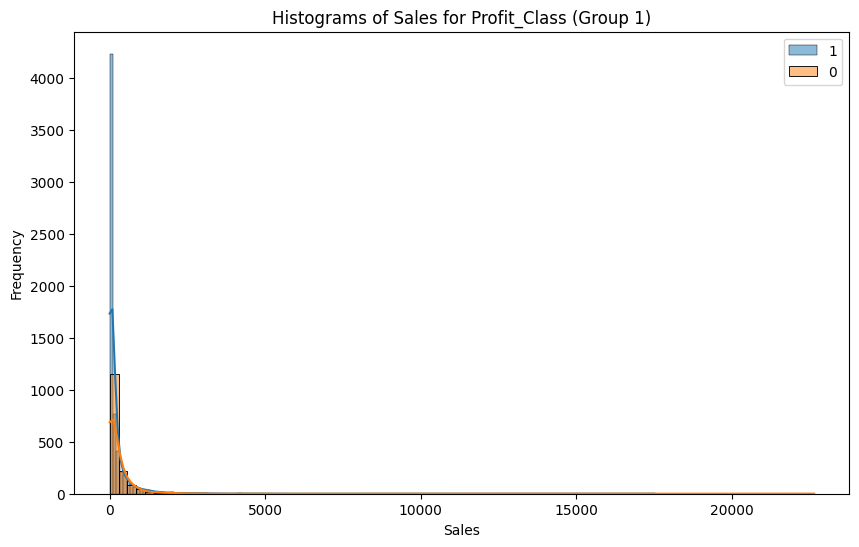

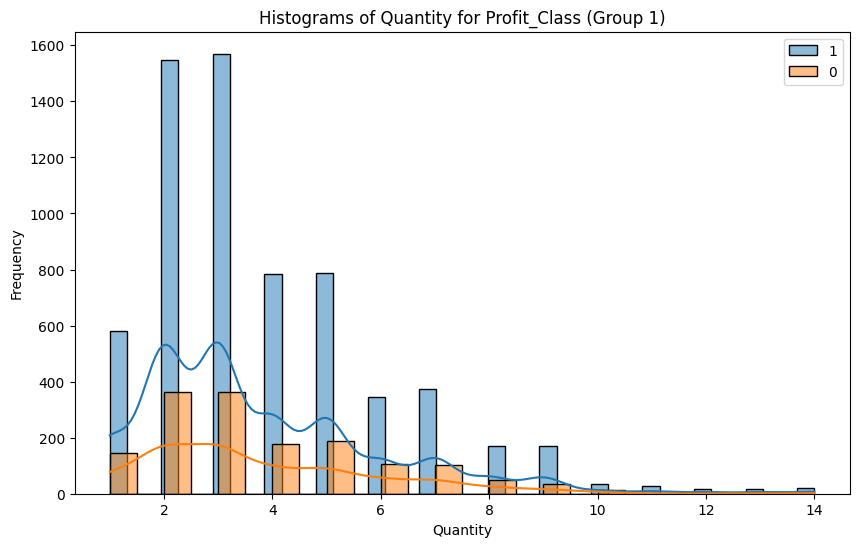

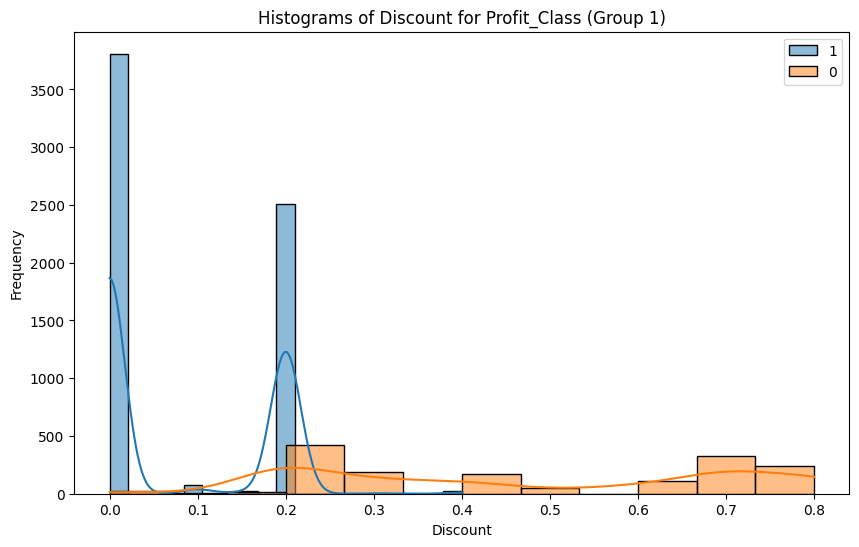

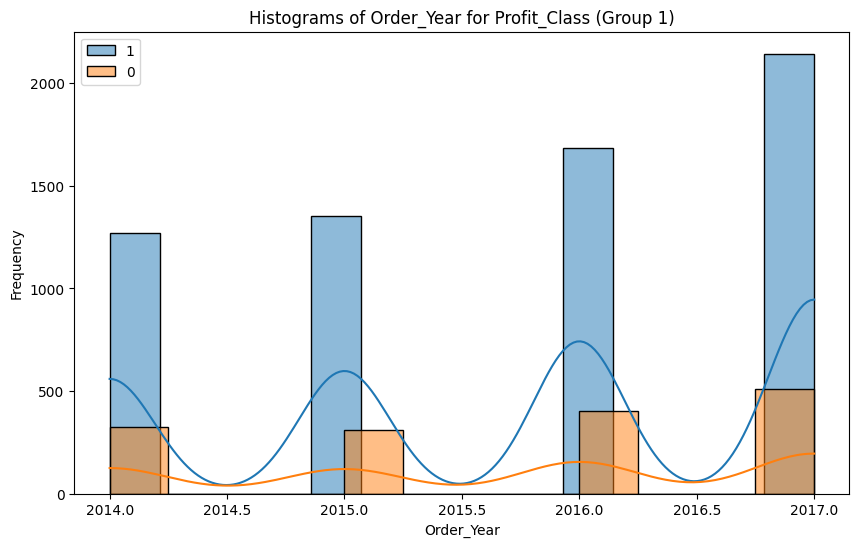

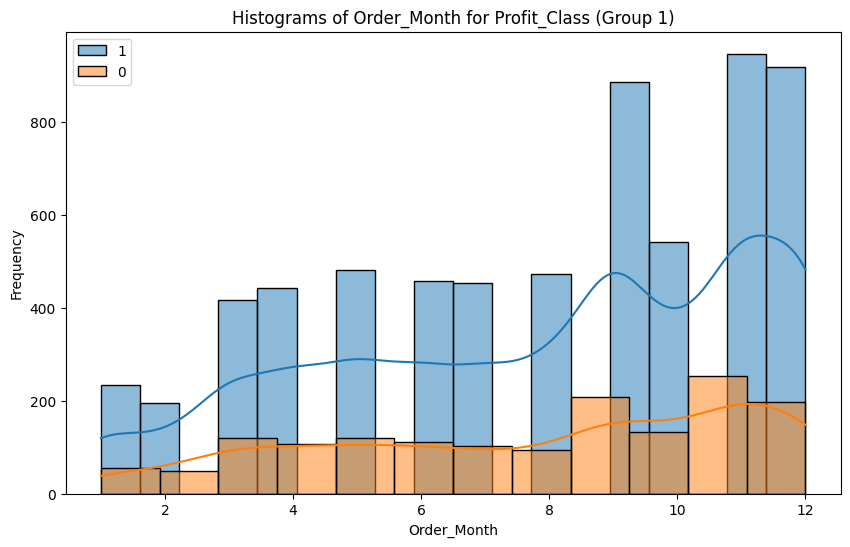

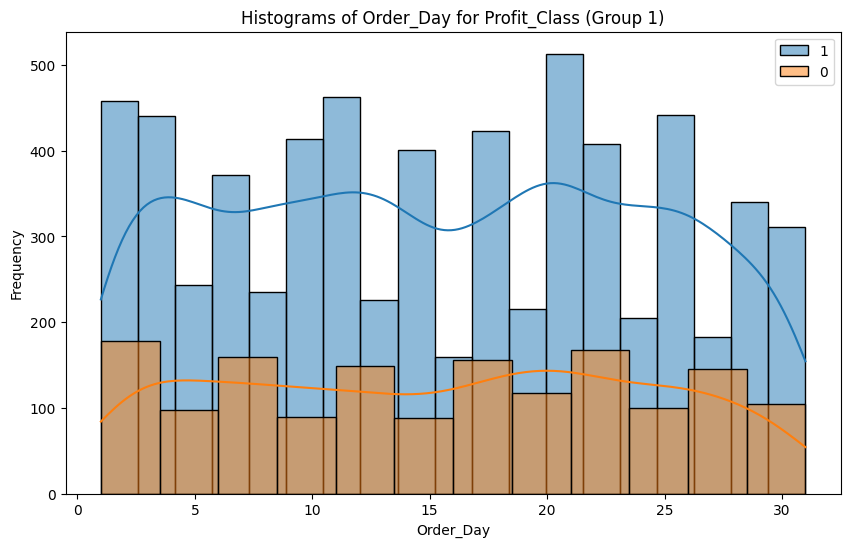

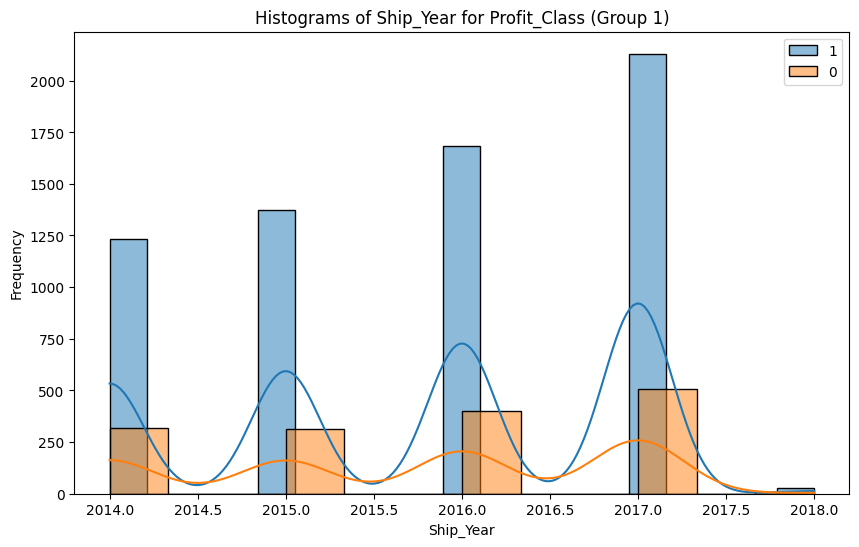

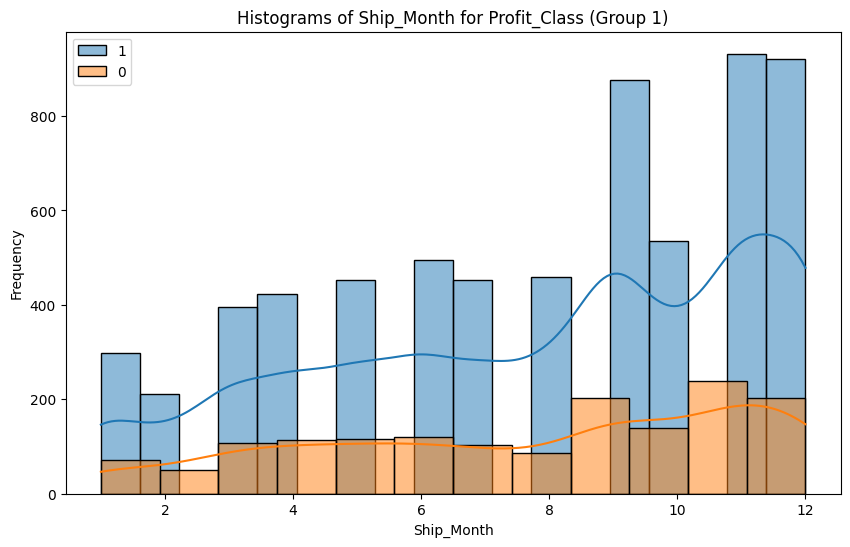

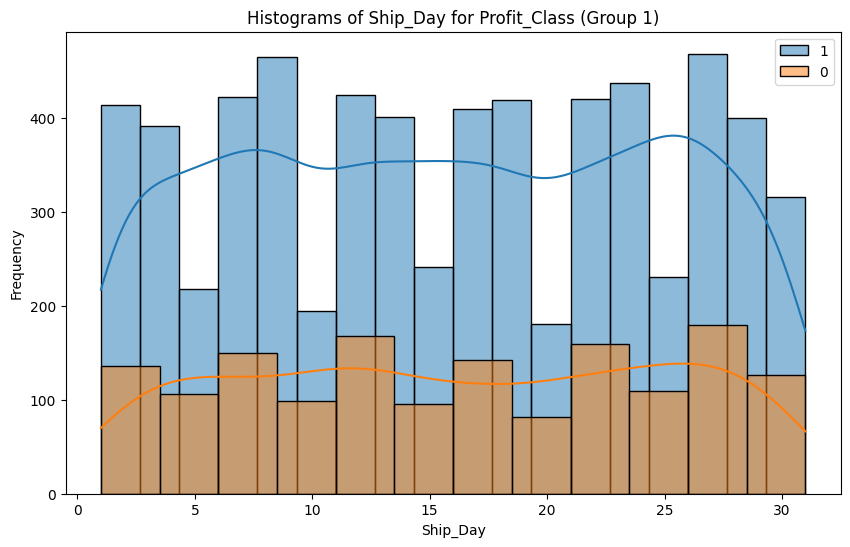

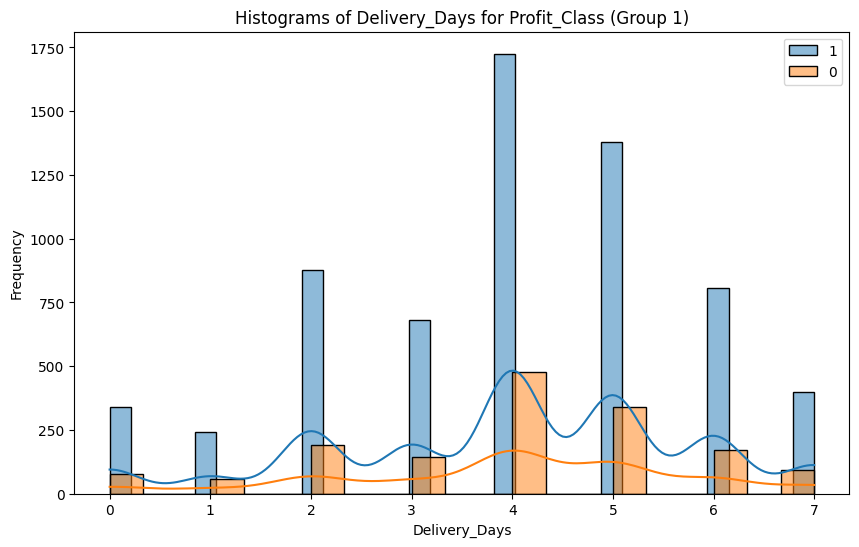

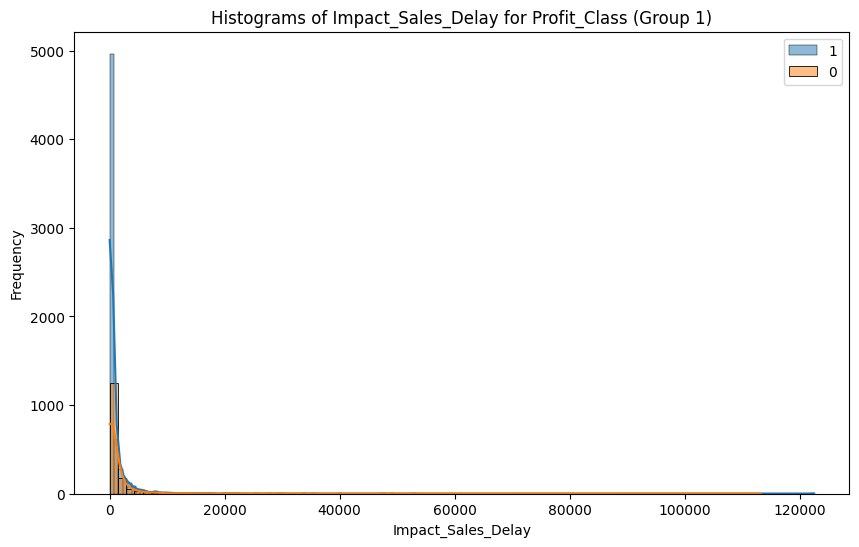

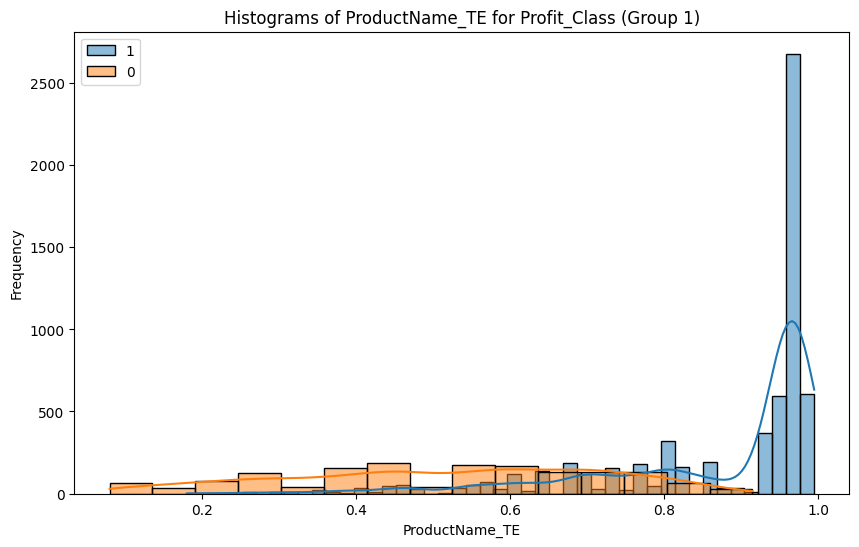

In [42]:
target = "Profit_Class"
X_train["Profit_Class"] = y_train

for col in features_num:
    bt.plot_grouped_histograms(X_train, cat_col= target, num_col= col, group_size= 2)

**Correlación**

In [43]:
X_train.corr(numeric_only=True)["Profit_Class"].sort_values(ascending=False)

Profit_Class          1.000000
ProductName_TE        0.657289
Ship_Month            0.011009
Order_Month           0.009918
Order_Year            0.007650
Ship_Year             0.007540
Order_Day             0.001322
Quantity             -0.005062
Delivery_Days        -0.005794
Ship_Day             -0.010168
Sales                -0.022892
Impact_Sales_Delay   -0.024191
Discount             -0.742567
Name: Profit_Class, dtype: float64

<Axes: >

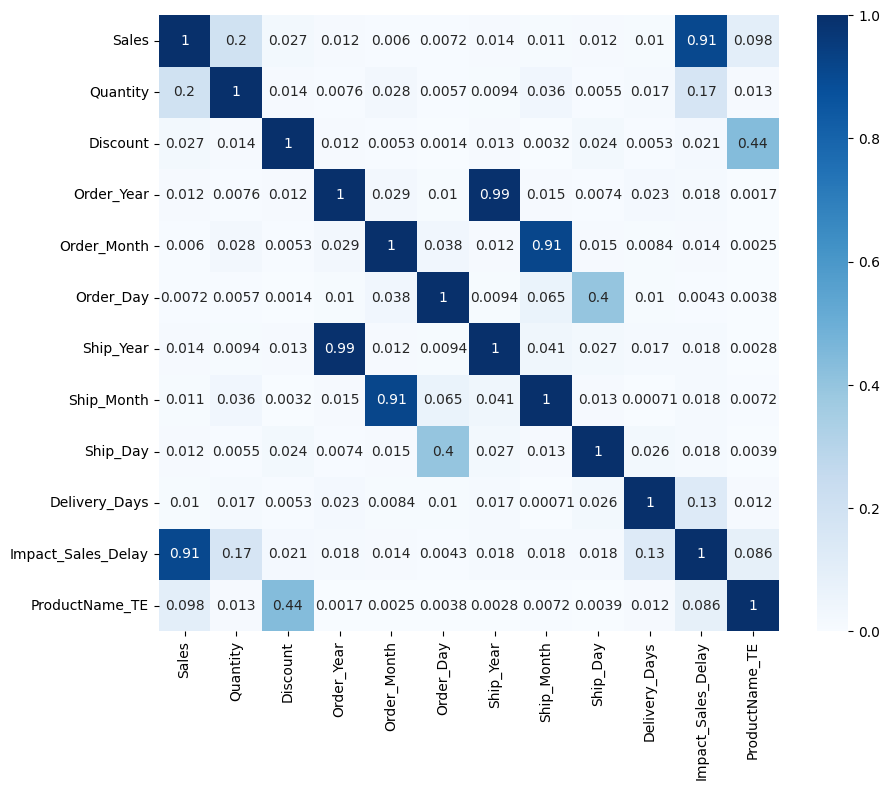

In [44]:
plt.figure(figsize= (10,8))
sns.heatmap(np.abs(X_train[features_num].corr(numeric_only= "True")), annot= True, cmap = "Blues", vmin= 0, vmax= 1)

- Por multicolinealidad con Order es mejor eliminar Ship Year, Ship_Month y Ship_day. 
- Tambien vamos a eliminar Sales porque genera colinealidad con impact_sales_delay.
- Order_day por su baja correlacion con el traget también la vamos a eliminar.

In [45]:
X_train = X_train.drop(columns=["Profit_Class"]) 

In [49]:
features_num_finales = [
  'Quantity',
  'Discount',
  'Order_Year',
  'Order_Month',
  'Delivery_Days',
  'Impact_Sales_Delay',
  'ProductName_TE'
]

In [54]:
X_train = X_train.drop( columns = ["Sales","Ship_Year", "Ship_Month", "Ship_Day", "Order_Day"])
X_test = X_test.drop( columns = ["Sales","Ship_Year", "Ship_Month", "Ship_Day", "Order_Day"])

### **8- Procesado de features categóricas**

In [47]:
X_train = pd.get_dummies(X_train, columns=features_cat, dtype=int)
X_test = pd.get_dummies(X_test, columns=features_cat, dtype=int)

# Alinear columnas para que ambos tengan exactamente las mismas
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

### **9- Tratamiento de features**

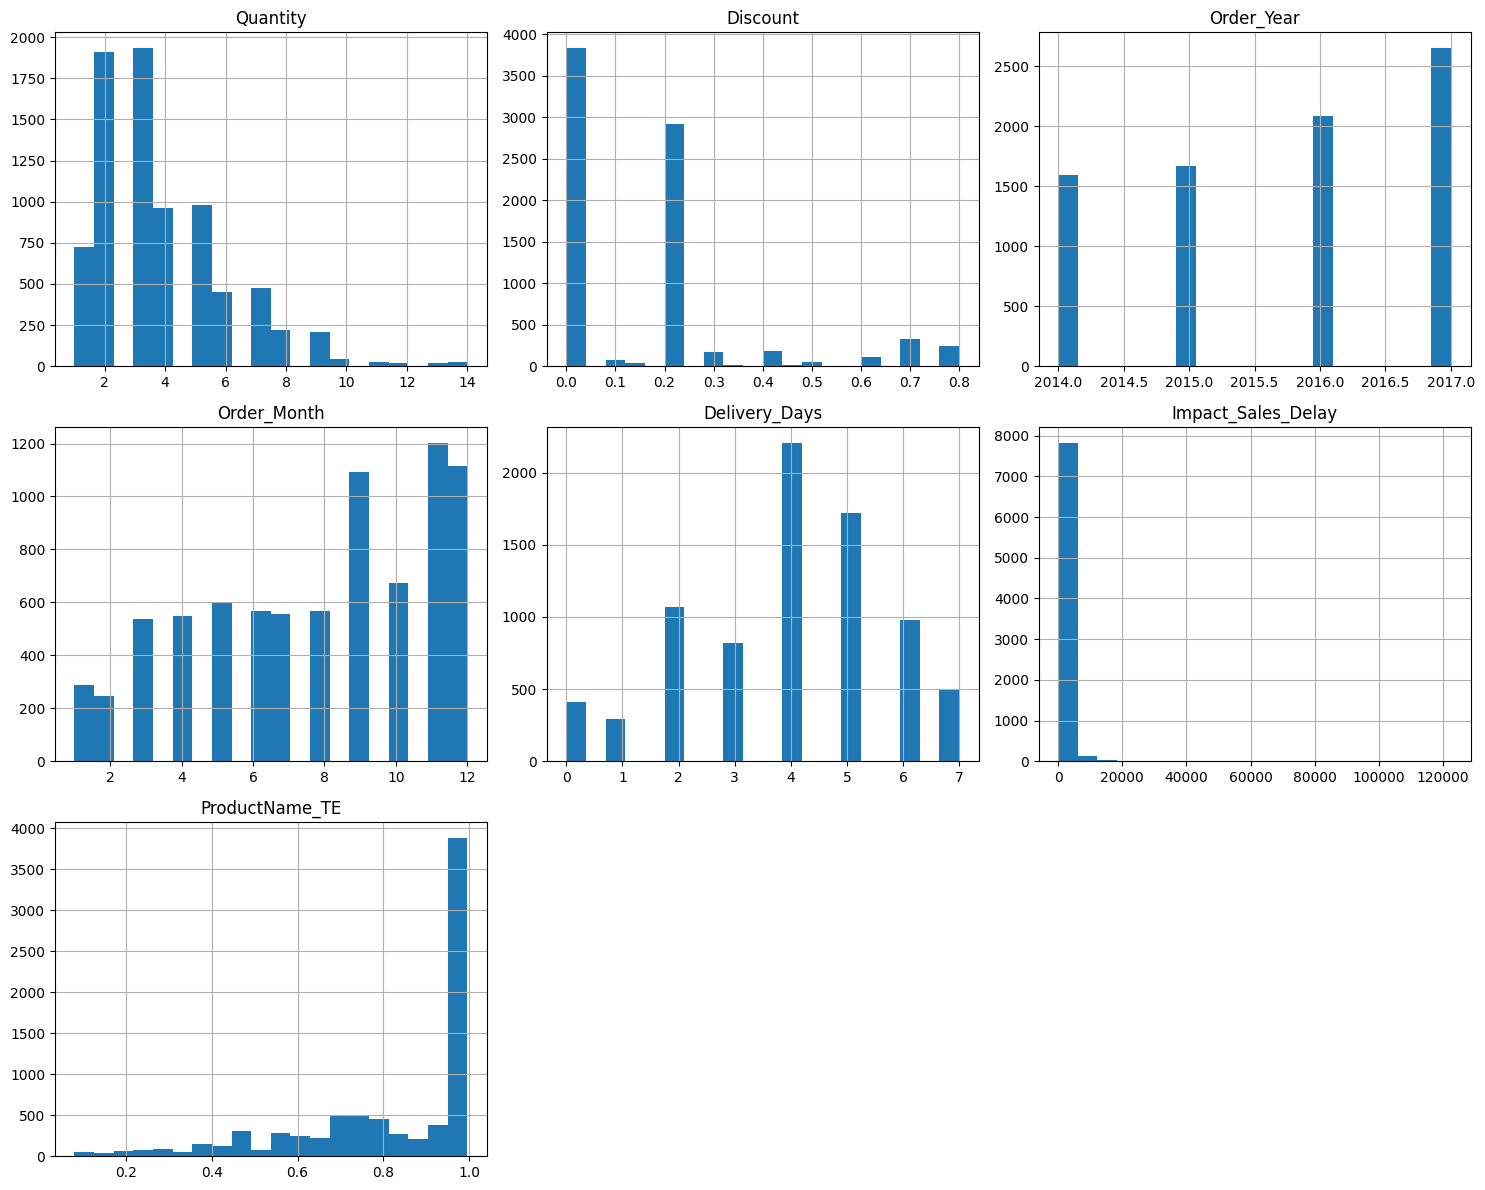

In [50]:
X_train[features_num_finales].hist(bins=20, figsize=(15, 12))
plt.tight_layout()

Las variables Impact_Sales_Delay y ProductName_TE presentan distribuciones fuertemente sesgadas hacia la derecha, con la mayoría de observaciones concentradas en valores bajos y colas largas. Para reducir este sesgo aplicaremos una transformación logarítmica con el objetivo de mejorar la capacidad del modelo para capturar patrones.


In [52]:
X_train["Impact_Sales_Delay"] = np.log1p(X_train["Impact_Sales_Delay"])
X_test["Impact_Sales_Delay"] = np.log1p(X_test["Impact_Sales_Delay"])

X_train["ProductName_TE"] = np.log1p(X_train["ProductName_TE"])
X_test["ProductName_TE"] = np.log1p(X_test["ProductName_TE"])

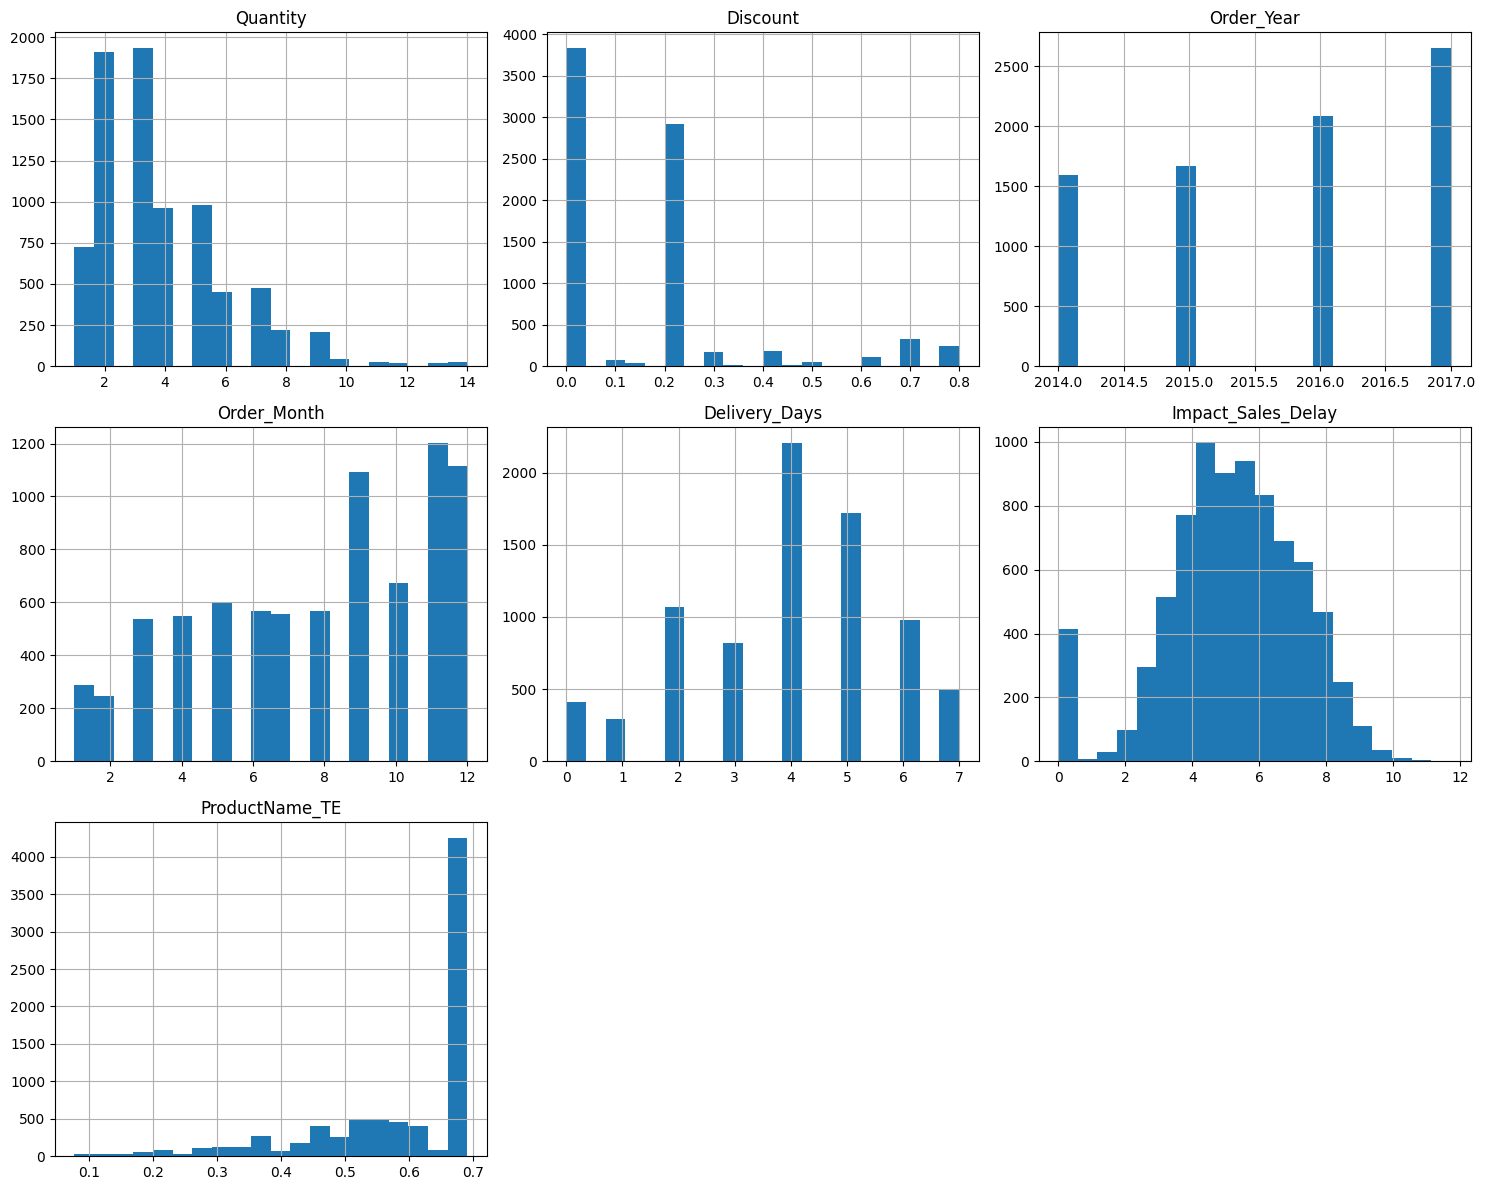

In [53]:
X_train[features_num_finales].hist(bins=20, figsize=(15, 12))
plt.tight_layout()

 La transformación logarítmica en ProductName_TE no produjo mejoras porque el rango de valores es estrecho y no contiene outliers extremos. Por este motivo es mejor aplicar un escalado para estabilizar la magnitud de la variable sin alterar su relación con el objetivo.

### **10- Normalización**

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[features_num_finales] = scaler.fit_transform(X_train[features_num_finales])
X_test[features_num_finales] = scaler.transform(X_test[features_num_finales])

In [57]:
X_train[features_num_finales].describe()

,Quantity,Discount,Order_Year,Order_Month,Delivery_Days,Impact_Sales_Delay,ProductName_TE
count,7.995000e+03,7.995000e+03,7.995000e+03,7.995000e+03,7.995000e+03,7.995000e+03,7.995000e+03
mean,4.177049e-17,-3.821556e-17,-5.131638e-14,-1.097586e-16,4.710290e-17,-1.448636e-16,6.665504e-17
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.251133e+00,-7.578476e-01,-1.536210e+00,-2.086471e+00,-2.262990e+00,-2.551454e+00,-3.836382e+00
25%,-8.025564e-01,-7.578476e-01,-6.456939e-01,-8.642831e-01,-5.469124e-01,-5.782162e-01,-4.523030e-01
50%,-3.539799e-01,2.118471e-01,2.448224e-01,3.579045e-01,2.511333e-02,3.531909e-02,5.937094e-01
75%,5.431732e-01,2.118471e-01,1.135339e+00,9.689984e-01,5.971391e-01,7.032726e-01,7.194903e-01
max,4.580362e+00,3.120931e+00,1.135339e+00,1.274545e+00,1.741191e+00,3.220404e+00,8.238203e-01


### **11- Modelado**

- ##### **Baseline -> Logistic Regression**

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.92       387
           1       0.97      0.99      0.98      1612

    accuracy                           0.97      1999
   macro avg       0.96      0.94      0.95      1999
weighted avg       0.97      0.97      0.97      1999



El baseline muestra un rendimiento muy alto en la clase 1 con un recall (0.99) lo que nos indica que el modelo identifica casi todos los pedidos con beneficio. Sin embargo, el recall de la clase 0 es menor (0.89), lo que refleja que el modelo tiene más dificultad para detectar pedidos con pérdida y tiende a clasificarlos como rentables.

- ##### **Métricas y valorazión de modelos**

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

# Métrica principal
scorer_recall = make_scorer(recall_score)


modelos = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "LightGBM",
    "XGBoost"
]

# Instancias de modelos

negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()
scale_pos_weight = negativos / positivos

lista_modelos = [
    LogisticRegression(max_iter=10000, class_weight="balanced"),
    DecisionTreeClassifier(max_depth=5, class_weight="balanced"),
    RandomForestClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    LGBMClassifier(max_depth=5, random_state=42, class_weight="balanced", verbose=-1),
    XGBClassifier(max_depth = 5, random_state = 42, scale_pos_weight =scale_pos_weight )
]



print("Evaluación con Recall (CV=5)\n")

resultados = {}

for nombre, modelo in zip(modelos, lista_modelos):
    print(f"Modelo: {nombre}")

    score = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=5,
        scoring=scorer_recall
    ).mean()

    resultados[nombre] = score
    print(f"Recall (CV=5): {score:.4f}\n")

Evaluación con Recall (CV=5)

Modelo: Logistic Regression
Recall (CV=5): 0.9842

Modelo: Decision Tree
Recall (CV=5): 0.9635

Modelo: Random Forest
Recall (CV=5): 0.9763

Modelo: LightGBM
Recall (CV=5): 0.9874

Modelo: XGBoost
Recall (CV=5): 0.9881



El modelo que arroja el mejor recall para la clase 0 es el XGBoost pero optimizaremos todos los modelos ya que el score podría cambiar.

- ##### **Optimización de hiperparámetros**

In [61]:
recall_0 = make_scorer(recall_score, pos_label=0)

# Calcular scale_pos_weight para XGBoost
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()
scale_pos_weight = negativos / positivos

param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(class_weight="balanced", max_iter=20000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "saga"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight="balanced"),
        "params": {
            "max_depth": [3, 5, 10, 15],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 15, 20],
            "min_samples_split": [2, 5]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(class_weight="balanced", random_state=42),
        "params": {
            "num_leaves": [31, 63],
            "max_depth": [-1, 10],
            "learning_rate": [0.05, 0.1]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss"
        ),
        "params": {
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1, 0.2],
            "n_estimators": [100, 200, 300]
        }
    }
}

In [62]:
from sklearn.model_selection import GridSearchCV

mejores_modelos = {}
resultados_recall = {}

for nombre, contenido in param_grids.items():
    print(f"\n Optimizando: {nombre}")

    grid = GridSearchCV(
        estimator=contenido["model"],
        param_grid=contenido["params"],
        scoring=recall_0,
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    mejores_modelos[nombre] = grid.best_estimator_
    resultados_recall[nombre] = grid.best_score_

    print(f"Mejor recall clase 0 (CV=5): {grid.best_score_:.4f}")
    print("Mejores hiperparámetros:", grid.best_params_)


 Optimizando: Logistic Regression
Mejor recall clase 0 (CV=5): 0.9845
Mejores hiperparámetros: {'C': 10, 'solver': 'saga'}

 Optimizando: Decision Tree
Mejor recall clase 0 (CV=5): 0.9832
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 10}

 Optimizando: Random Forest
Mejor recall clase 0 (CV=5): 0.9593
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

 Optimizando: LightGBM
Mejor recall clase 0 (CV=5): 0.9813
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 10, 'num_leaves': 31}

 Optimizando: XGBoost
Mejor recall clase 0 (CV=5): 0.9897
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}


El mejor modelo optimizado sigue siendo el XGBoost, veremos si contra el Test el recall sigue siendo el mejor.

- ##### **Evaluación contra Test**

In [63]:
for nombre, modelo in mejores_modelos.items():
    print(f"\nModelo: {nombre}")

    y_pred = modelo.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Modelo: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       387
           1       0.99      0.98      0.98      1612

    accuracy                           0.97      1999
   macro avg       0.95      0.96      0.95      1999
weighted avg       0.97      0.97      0.97      1999


Modelo: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       387
           1       0.96      0.98      0.97      1612

    accuracy                           0.95      1999
   macro avg       0.93      0.91      0.92      1999
weighted avg       0.95      0.95      0.95      1999


Modelo: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       387
           1       0.98      0.98      0.98      1612

    accuracy                       

Aunque XGBoost obtuvo buenos resultados durante la validación, en el conjunto de test el modelo que mejor generalizó fue Logistic Regression. Con un recall superior en la clase minoritaria (0.94) frente a (0.85), lo que lo convierte en el modelo más adecuado para este problema.

- **Análisis de coeficientes**

In [ ]:
coef = log_reg.coef_[0]

importancias = pd.DataFrame({
    "feature": X_train.columns,
    "coeficiente": coef,
    "importancia_abs": np.abs(coef)
}).sort_values("importancia_abs", ascending=False)

importancias

,feature,coeficiente,importancia_abs
1,Discount,-6.601754,6.601754
24,Sub-Category_Binders,4.331818,4.331818
6,ProductName_TE,3.323628,3.323628
35,Sub-Category_Storage,-3.184200,3.184200
21,Sub-Category_Accessories,-2.875259,2.875259
...,...,...,...
40,State_grouped_Arkansas,0.001597,0.001597
45,State_grouped_District of Columbia,0.001399,0.001399
51,State_grouped_Iowa,0.001097,0.001097
55,State_grouped_Maine,-0.000220,0.000220


El análisis de coeficientes muestra que la rentabilidad está fuertemente influida por el descuento aplicado, la subcategoría del producto y el propio producto. Las variables geográficas presentan coeficientes cercanos a cero, lo que muestra que estas variables apenas contribuyen a la capacidad predictiva del modelo. Al final, el modelo funciona principalmente gracias a un grupo reducido de variables que realmente marcan la diferencia, y su comportamiento encaja bien con la lógica del negocio.

### **12- Guardamos el modelo**

In [77]:
joblib.dump(log_reg, "src/models/logistic_regression.joblib")
modelo = joblib.load("src/models/logistic_regression.joblib")

### **13- Creamos un dataframe**-> que nos muestre qué productos realmente generan pérdidas según el modelo

In [64]:
mejor_modelo = mejores_modelos["Logistic Regression"]
y_pred = mejor_modelo.predict(X_test)

In [65]:
df_resultados = df.loc[X_test.index].copy()
df_resultados["y_real"] = y_test.values
df_resultados["y_pred"] = y_pred

- **Productos que el modelo predice como pérdida**

In [69]:
productos_pred_perdida = df_resultados[df_resultados["y_pred"] == 0]

productos_pred_perdida[ ["Product_Name", "City", "Category", "Sub-Category", "Sales", "Quantity", "Discount"]].head(20)

,Product_Name,City,Category,Sub-Category,Sales,Quantity,Discount
2424,Satellite Sectional Post Binders,Fairfield,Office Supplies,Binders,13.023,1,0.7
1333,Holmes Cool Mist Humidifier for the Whole Hous...,Dallas,Office Supplies,Appliances,7.960,2,0.8
8720,Global Enterprise Series Seating High-Back Swi...,Houston,Furniture,Chairs,379.372,2,0.3
3687,Avery Non-Stick Binders,Port Saint Lucie,Office Supplies,Binders,2.694,2,0.7
9123,Binding Machine Supplies,Philadelphia,Office Supplies,Binders,78.759,9,0.7
1112,Avery Hidden Tab Dividers for Binding Systems,Houston,Office Supplies,Binders,1.192,2,0.8
4541,Storex DuraTech Recycled Plastic Frosted Binders,Chicago,Office Supplies,Binders,5.936,7,0.8
976,Wilson Jones Easy Flow II Sheet Lifters,Portland,Office Supplies,Binders,1.080,2,0.7
2579,"SAFCO Commercial Wire Shelving, 72h",Alexandria,Office Supplies,Storage,489.920,8,0.0
9577,"Global Stack Chair with Arms, Black",San Antonio,Furniture,Chairs,104.930,5,0.3


- **Productos que en verdad generaron pérdidas en el pasado**

In [70]:
productos_real_perdida = df_resultados[df_resultados["y_real"] == 0]

productos_real_perdida[ ["Product_Name", "City", "Category", "Sub-Category", "Sales", "Quantity", "Discount"]].head(20)

,Product_Name,City,Category,Sub-Category,Sales,Quantity,Discount
2424,Satellite Sectional Post Binders,Fairfield,Office Supplies,Binders,13.023,1,0.7
1333,Holmes Cool Mist Humidifier for the Whole Hous...,Dallas,Office Supplies,Appliances,7.960,2,0.8
8720,Global Enterprise Series Seating High-Back Swi...,Houston,Furniture,Chairs,379.372,2,0.3
3687,Avery Non-Stick Binders,Port Saint Lucie,Office Supplies,Binders,2.694,2,0.7
9123,Binding Machine Supplies,Philadelphia,Office Supplies,Binders,78.759,9,0.7
1112,Avery Hidden Tab Dividers for Binding Systems,Houston,Office Supplies,Binders,1.192,2,0.8
4541,Storex DuraTech Recycled Plastic Frosted Binders,Chicago,Office Supplies,Binders,5.936,7,0.8
976,Wilson Jones Easy Flow II Sheet Lifters,Portland,Office Supplies,Binders,1.080,2,0.7
4670,Fellowes Staxonsteel Drawer Files,Fort Worth,Office Supplies,Storage,772.680,5,0.2
7836,Global Super Steno Chair,Seattle,Furniture,Chairs,307.136,4,0.2
